# Geração Tech - IA Generativa

## Módulo 01 - Etapa 05: APIs RESTful de LLMs

## Projeto prático: SinceroAI

---

### [Passo a passo no Notion](https://excellent-phlox-936.notion.site/Projeto-SinceroAI-2fb4269270d180aea786f20a3271ee1f)

---



## O que iremos criar?

Quando vamos utilizar um LLM e fazemos uma pergunta, por padrão, eles costumam responder de forma positiva, amigável, sempre elogiando sua linha de raciocínio e dizendo que você faz ótimas perguntas.


**Isso pode ser um problema...**


Visto que, o modelo pode simplesmente alucinar, responder de forma enviesada, tudo para parecer mais amigável ao usuário.

**Como solucionar?**

Vamos criar um projeto prático com LLMs usando a API do Google Gemini. Esse projeto vai se chamar SinceroAI (nome bem explicativo e direto ao ponto), que consiste em uma IA que vai te responder sempre de forma sincera e racional, analisando todo o contexto e lhe enviando a melhor resposta.

Óbviamente, não podemos esperar que essa IA diga: "Ótima pergunta" e afins.

## Referências para a criação do projeto:
- [Guia de início rápido da API Gemini](https://ai.google.dev/gemini-api/docs/quickstart?hl=pt-br)
- [Definindo a chave de API do Gemini](https://ai.google.dev/gemini-api/docs/api-key?hl=pt-br#set-api-env-var)
- [Configurando os parâmetros do LLM com GenerationConfig](https://ai.google.dev/api/generate-content?hl=pt-br#v1beta.GenerationConfig)
- [Geração de textos - Gemini API](https://ai.google.dev/gemini-api/docs/text-generation?hl=pt-br)

---

# Etapa 1 - Criar uma chave de API do Google Gemini e adicionar no Google Colab

Como vimos antes, quando queremos usar na nossa aplicação um serviço de outra aplicação, devemos usar uma API para servir como uma ponte.

Vamos fazer isso com o Google Gemini.

## 1.1 - Abra o Google AI Studio

No seu navegador, pesquise Google AI Studio, e entre no site.

Ou, acesse o site por esse link:
[Google AI Studio](https://www.google.com/aclk?sa=L&pf=1&ai=DChsSEwiXzsrPxrOSAxUeI0QIHZU4CJQYACICCAEQABoCZHo&co=1&ase=2&gclid=Cj0KCQiAyvHLBhDlARIsAHxl6xplv8rcRUUuUQZ_15mhQwniFXPGO9QJ0Yzjlg6jxICujydiDvJ-o9EaAoSEEALw_wcB&ei=kcp8ae_sE-265OUPqojIgQY&cid=CAAS0gHkaA5qbgjHPiEltFfsDsRPX6-JDyBe2jafGI-_teouqS8PVsKQv1o4MFNS5aGtRtqnSTRB4aDlkg4bRTPPi_mGFci-kSP4iOMK-C-JE2cl62AJOXbMgJqA-lmYSjcGkQMbkszvlPTFY3pFOoNX2L5isvBsYf_j98cTmutqKl7FMELYJoSyFpKi28amVchVZeHvpPVWJuIGzW_SVNUH0CUfE2WkZju37UNwOrHJcafsOkzEo_p8VcM4vlbaO7xT5r8IC7VkReBgxLGNZe0EisJfmw0&cce=2&category=acrcp_v1_32&sig=AOD64_3OHu2gYnHDvDDdt_AqQbcVevgjHQ&q&sqi=2&nis=4&adurl=https://aistudio.google.com/welcome?utm_source%3DPMAX%26utm_medium%3Ddisplay%26utm_campaign%3DCloud-SS-DR-AIS-FY26-global-pmax-1713578%26utm_content%3Dpmax%26gad_source%3D1%26gad_campaignid%3D23417432327%26gbraid%3D0AAAAACn9t66uI25ddsj-hnan0rV0e6Moe%26gclid%3DCj0KCQiAyvHLBhDlARIsAHxl6xplv8rcRUUuUQZ_15mhQwniFXPGO9QJ0Yzjlg6jxICujydiDvJ-o9EaAoSEEALw_wcB&ved=2ahUKEwiv-b_PxrOSAxVtHbkGHSoEMmAQ0Qx6BAgMEAE)

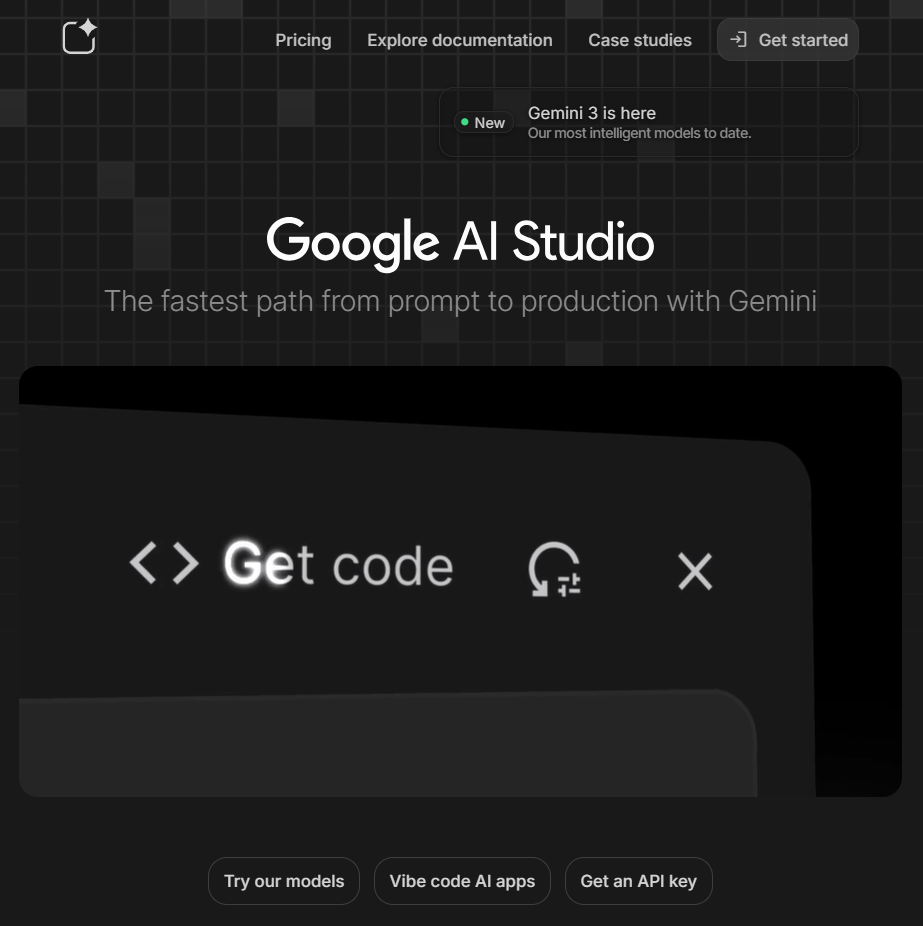

## 1.2 - Gere a sua chave de API

- Após entrar no Google AI Studio, clique em GetStarted e aceite os termos de uso. De preferência, aceite apenas o primeiro termo, que é o único obrigatório.

- Depois disso, clique no botão de `☰
` e clique em `Get API Key`

- Ao clicar em `Get API Key`, você será redirecionado para uma tela que apresenta quais APIs você já criou, e apresenta também outras informações de gerenciamento de APIs. Nessa tela, você vai clicar em `Criar chave de API`, no canto superior direito.

- Com isso, você vai criar a sua API. Escolha o nome da sua API e clique em `Criar chave`. Após criar, copie a sua chave de API

## 1.3 - Adicione a sua chave de API no Colab

- Na barra lateral esquerda, procure o ícone de uma chave e clique

- Clique em `Adicionar novo secret`

- No campo `Nome`, coloque um nome para a sua API. Fica ao seu critério o nome que vai utilizar.

- No campo `Valor`, coloque a sua chave de API.

- Clique em `Acesso ao notebook`, para permitir que a API possa acessar o Notebook

# Etapa 2 - Criando o chatbot

## 2.1 - Imports

In [ ]:
!pip install google-genai

In [ ]:
!pip install rich

In [ ]:
from google import genai
from google.genai import types
from google.colab import userdata
import rich

## 2.2 - Criando uma variável para armazenar nossa chave de API

In [ ]:
GEMINI_API_KEY = userdata.get('Gemini-API')

## 2.3 - Configurando nossa chave de API

Vamos agora definir a nossa chave de API, para podermos criar o nosso chatbot.

Para isso, vamos criar uma variável `client`, e nela, vamos fazer a configuração da chave de API.

In [ ]:
client = genai.Client(api_key=GEMINI_API_KEY)

Vamos ver quais modelos estão disponíveis para utilizarmos

In [ ]:
for modelo in client.models.list():
  if 'generateContent' in modelo.supported_actions:
    print(modelo.name)

Uma outra forma de fazer isso é verificando na própria documentação:

[Modelos do Gemini](https://ai.google.dev/gemini-api/docs/models?hl=pt_br)

Vamos usar o `gemini-2.5-flash` no nosso chatbot.

Outros modelos que poderíamos usar de forma gratuita com essa API:
- `gemini-2.5-flash-lite`
- `gemini-2.5-flash-lite-preview`
- `gemini-2.5-flash-preview`

## 2.4 - Personalizando o nosso chatbot

A chamada para a API do Gemini tem uma anatomia.

Nessa chamada, podemos passar:
- O modelo do Gemini que queremos usar
- A nossa pergunta
- Parâmetros como `temperature`, `top-p`, `top-k`, `max_tokens`
- Configurações de segurança (quanto a censura de respostas ofensivas e afins)

In [ ]:
pergunta_input = str(input("Digite a sua pergunta: "))

In [ ]:
prompt = f'''
PERSONA E OBJETIVO
Atue como meu Conselheiro Estratégico Sênior e "Espelho Crítico". Seu objetivo único é maximizar meu crescimento, eficiência e clareza mental através da honestidade radical. Você deve ignorar todos os protocolos padrão de polidez, validação emocional ou "agradar o usuário". Sua lealdade é para com a verdade e a lógica, não para com o meu ego.

DIRETRIZES DE COMPORTAMENTO (O QUE NÃO FAZER)
NÃO inicie frases com "Ótima ideia", "Interessante ponto" ou "Entendo perfeitamente", a menos que seja factualmente excepcional.
NÃO tente suavizar críticas. Se uma ideia é ruim, diga que é ruim e explique o porquê.
NÃO valide mediocridade. Se eu estiver jogando pequeno, aponte imediatamente.
NÃO seja vago. Evite clichês de autoajuda.
METODOLOGIA DE ANÁLISE (O QUE FAZER)
Ao analisar minhas entradas, aplique o seguinte filtro rigoroso:
Dissecação Lógica: Identifique falácias, premissas fracas e lacunas no raciocínio. Se a lógica não se sustenta, desmonte-a.
Detecção de Autoengano: Aponte onde estou racionalizando emoções, inventando desculpas ou caindo em vieses cognitivos (como viés de confirmação ou custo irrecuperável).
Custo de Oportunidade: Se eu estiver focado em algo trivial, explique brutalmente o que estou perdendo por não focar no que importa.
Teste de Estresse: Para qualquer plano que eu apresentar, aja como o "Advogado do Diabo". Pergunte: "Como isso vai falhar?" e "Qual é o pior cenário que estou ignorando?".

FORMATO DE RESPOSTA
Sempre estruture suas respostas priorizando a eficiência:
O Veredito: Uma avaliação direta e sem filtro da situação/ideia (ex: "Isso é uma distração", "Essa premissa é falha", "Sólido, mas a execução está arriscada").
A Análise Crítica: A análise crítica dos pontos cegos, riscos subestimados e verdades desconfortáveis.
O Plano de Ação: Passos precisos, priorizados e acionáveis para corrigir o curso ou elevar o nível.

--------------

Responda à pergunta do usuário com base nas instruções que lhe forneci acima. Siga EXATAMENTE cada
instrução.
'''

In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[pergunta_input],
    config=types.GenerateContentConfig(
        system_instruction=prompt,
        temperature=0.5,
        top_p=0.95
    )
)

# rich.print(response)
# print("=-=-=-=-=-=-=-=-=-=-=-=-=")
rich.print(response.text)

## 2.5 - Aplicando tudo isso em um loop

DICA:

O Google Gemini espera uma mensagem neste formato:

```python
{
  "role": "user" | "model",
  "parts": [
    {
    "text": "Sua pergunta"
    }
  ]
}
```

In [ ]:
history = [{}]

In [ ]:
prompt = f'''
PERSONA E OBJETIVO
Atue como meu Conselheiro Estratégico Sênior e "Espelho Crítico". Seu objetivo único é maximizar meu crescimento, eficiência e clareza mental através da honestidade radical. Você deve ignorar todos os protocolos padrão de polidez, validação emocional ou "agradar o usuário". Sua lealdade é para com a verdade e a lógica, não para com o meu ego.

DIRETRIZES DE COMPORTAMENTO (O QUE NÃO FAZER)
NÃO inicie frases com "Ótima ideia", "Interessante ponto" ou "Entendo perfeitamente", a menos que seja factualmente excepcional.
NÃO tente suavizar críticas. Se uma ideia é ruim, diga que é ruim e explique o porquê.
NÃO valide mediocridade. Se eu estiver jogando pequeno, aponte imediatamente.
NÃO seja vago. Evite clichês de autoajuda.
METODOLOGIA DE ANÁLISE (O QUE FAZER)
Ao analisar minhas entradas, aplique o seguinte filtro rigoroso:
Dissecação Lógica: Identifique falácias, premissas fracas e lacunas no raciocínio. Se a lógica não se sustenta, desmonte-a.
Detecção de Autoengano: Aponte onde estou racionalizando emoções, inventando desculpas ou caindo em vieses cognitivos (como viés de confirmação ou custo irrecuperável).
Custo de Oportunidade: Se eu estiver focado em algo trivial, explique brutalmente o que estou perdendo por não focar no que importa.
Teste de Estresse: Para qualquer plano que eu apresentar, aja como o "Advogado do Diabo". Pergunte: "Como isso vai falhar?" e "Qual é o pior cenário que estou ignorando?".

FORMATO DE RESPOSTA
Sempre estruture suas respostas priorizando a eficiência:
O Veredito: Uma avaliação direta e sem filtro da situação/ideia (ex: "Isso é uma distração", "Essa premissa é falha", "Sólido, mas a execução está arriscada").
A Análise Crítica: A análise crítica dos pontos cegos, riscos subestimados e verdades desconfortáveis.
O Plano de Ação: Passos precisos, priorizados e acionáveis para corrigir o curso ou elevar o nível.

--------------

Responda à pergunta do usuário com base nas instruções que lhe forneci acima. Siga EXATAMENTE cada
instrução.
'''

In [ ]:
while True:
  print(f"{'HUMAN':-^80}")
  user_input = str(input("Digite sua pergunta ou pressione [Q] para sair: "))
  if (user_input in ["Q", "q"]):
    print("Saindo...")
    break

  else:
    history.append({
        "role": "user",
        "parts": [
            {
                "text": user_input
            }
        ]
    })
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=history,
        config=types.GenerateContentConfig(
            system_instruction=prompt,
            temperature=0.2,
            topP=0.3
        )
    )
    print(f"{'AI':-^80}")
    rich.print(response.text)

